<a href="https://colab.research.google.com/github/MarceCorreal2/Robots-NT/blob/main/Procesamiento_Datos_Trades_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Celda 1 — Importes y configuración

import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

In [26]:
# Celda 2 — Conectar Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Definir Parámetros de Prueba

### Subtask:
Establecer variables para el nombre del bot, el instrumento y el número de prueba (por ejemplo, 'T001', 'T002') para construir rutas de archivo dinámicamente.

In [27]:
# Celda 3 — Definir Parámetros de Ruta Dinámicos

# Definir los componentes del nombre del bot y el archivo
robot_name = 'RB003' # Nombre del robot
instrument = 'MNQ'   # Instrumento
version_suffix = 'A' # Sufijo de versión (constante en este caso)
test_number = 'T001' # Número de la prueba (ej. 'T001', 'T002')

print(f"Robot Name: {robot_name}")
print(f"Instrument: {instrument}")
print(f"Version Suffix: {version_suffix}")
print(f"Test Number: {test_number}")

Robot Name: RB003
Instrument: MNQ
Version Suffix: A
Test Number: T001


## Generar Rutas de Archivo Dinámicas

### Subtask:
Construir las rutas completas para el archivo CSV de datos crudos, el archivo CSV de datos limpios y el directorio de guardado de gráficas, utilizando los parámetros de prueba definidos.

In [28]:
# Celda 4 - Generación rutas dinámicas

import os

# 1. Define base path for raw data files
raw_data_base_path = '/content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Crudos/'

# 2. Define base path for cleaned data files
cleaned_data_base_path = '/content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Limpios/'

# 3. Define base path for graph output
graph_output_base_path = '/content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/'

# Construir el nombre base del archivo completo (ej. RB003_MNQ_A_T001)
full_file_base_name = f'{robot_name}_{instrument}_{version_suffix}_{test_number}'

# 4. Construct full file path for raw CSV data
raw_data_file_path = os.path.join(raw_data_base_path, f'{full_file_base_name}.csv')

# 5. Construct full file path for cleaned CSV data
cleaned_data_file_path = os.path.join(cleaned_data_base_path, f'{full_file_base_name}_limpio.csv')

# 6. Construct full directory path for graphs
graph_output_directory = os.path.join(graph_output_base_path, full_file_base_name)

# 7. Print all generated paths for verification
print(f"Ruta de archivo de datos crudos: {raw_data_file_path}")
print(f"Ruta de archivo de datos limpios: {cleaned_data_file_path}")
print(f"Directorio de salida de gráficas: {graph_output_directory}")

Ruta de archivo de datos crudos: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Crudos/RB003_MNQ_A_T001.csv
Ruta de archivo de datos limpios: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Limpios/RB003_MNQ_A_T001_limpio.csv
Directorio de salida de gráficas: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/RB003_MNQ_A_T001


## Cargar Datos Crudos

### Subtask:
Cargar el archivo CSV de datos crudos utilizando la ruta generada dinámicamente. Este paso reemplazará la selección manual del archivo.

In [29]:
# Celda 5 — Carga de archivo crudo  CSV

df_raw = pd.read_csv(
    raw_data_file_path,
    sep=';',
    dtype={'Entry time': str, 'Exit time': str},
    keep_default_na=False,
    na_values=[]
).copy()

df_raw = df_raw.loc[:, ~df_raw.columns.str.contains('Unnamed')].copy()
df = df_raw.copy()

print(f"DataFrame cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())

DataFrame cargado con 804 filas y 23 columnas.


,Trade number,Instrument,Account,Strategy,Market pos.,Qty,Entry price,Exit price,Entry time,Exit time,Entry name,Exit name,Profit,Cum. net profit,Commission,Clearing Fee,Exchange Fee,IP Fee,NFA Fee,MAE,MFE,ETD,Bars
0,1,MNQ SEP26,Backtest,RB003,Long,1,"25994,75","25994,50",1/01/2026 6:22:00 p m,1/01/2026 6:30:00 p m,Buy,Sell,"-$ 2,40","-$ 2,40","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 3,50","$ 20,50","$ 22,90",9
1,2,MNQ SEP26,Backtest,RB003,Long,1,"26007,00","26001,25",1/01/2026 6:34:00 p m,1/01/2026 6:42:00 p m,Buy,Sell,"-$ 13,40","-$ 15,80","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 20,50","$ 2,50","$ 15,90",9
2,3,MNQ SEP26,Backtest,RB003,Long,1,"26016,50","26014,00",1/01/2026 7:33:00 p m,1/01/2026 7:38:00 p m,Buy,Sell,"-$ 6,90","-$ 22,70","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 10,00","$ 3,00","$ 9,90",6
3,4,MNQ SEP26,Backtest,RB003,Long,1,"26149,50","26147,50",2/01/2026 1:41:00 a m,2/01/2026 1:50:00 a m,Buy,Sell,"-$ 5,90","-$ 28,60","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 4,50","$ 21,00","$ 26,90",10
4,5,MNQ SEP26,Backtest,RB003,Long,1,"26146,25","26148,00",2/01/2026 2:26:00 a m,2/01/2026 2:48:00 a m,Buy,Sell,"$ 1,60","-$ 27,00","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 6,50","$ 15,00","$ 13,40",23


### Diagnóstico de Columnas del DataFrame

El error `KeyError: 'Entry time'` indica que la columna `Entry time` no se encuentra en el DataFrame `df`. Esto sugiere que el archivo CSV cargado en la 'Celda 5' no tiene las columnas esperadas para los pasos de limpieza y visualización. La siguiente celda de código realizará una verificación de las columnas presentes en tu DataFrame.

In [30]:
# Celda 6 - Diagnóstico: Comprobar las columnas del DataFrame

expected_date_cols = ["Entry time", "Exit time"]
expected_numeric_cols_for_cleaning = [
    "Entry price", "Exit price", "Profit", "Cum. net profit",
    "Commission", "Clearing Fee", "Exchange Fee", "IP Fee",
    "NFA Fee", "MAE", "MFE", "ETD"
]
expected_plot_cols = ["Trade number"]

all_expected_cols = list(set(expected_date_cols + expected_numeric_cols_for_cleaning + expected_plot_cols))

print("Columnas actuales en el DataFrame 'df':")
print(df.columns.tolist())
print("\nColumnas esperadas para limpieza y graficación:")
print(all_expected_cols)

missing_cols = [col for col in all_expected_cols if col not in df.columns]

if missing_cols:
    print(f"\nERROR: Las siguientes columnas esenciales faltan en el DataFrame: {missing_cols}")
    print(f"Por favor, verifica el archivo CSV ubicado en: {raw_data_file_path}")
    print("Asegúrate de que el archivo CSV contenga estas columnas con la ortografía y el uso de mayúsculas y minúsculas exactos.")
else:
    print("\nTodas las columnas esperadas están presentes en el DataFrame.")


Columnas actuales en el DataFrame 'df':
['Trade number', 'Instrument', 'Account', 'Strategy', 'Market pos.', 'Qty', 'Entry price', 'Exit price', 'Entry time', 'Exit time', 'Entry name', 'Exit name', 'Profit', 'Cum. net profit', 'Commission', 'Clearing Fee', 'Exchange Fee', 'IP Fee', 'NFA Fee', 'MAE', 'MFE', 'ETD', 'Bars']

Columnas esperadas para limpieza y graficación:
['Entry time', 'NFA Fee', 'MAE', 'MFE', 'Cum. net profit', 'Commission', 'Exit time', 'Exit price', 'IP Fee', 'Trade number', 'Entry price', 'ETD', 'Exchange Fee', 'Clearing Fee', 'Profit']

Todas las columnas esperadas están presentes en el DataFrame.


## Limpiar y Preprocesar Datos

### Subtask:
Aplicar las operaciones de limpieza y preprocesamiento de columnas de fecha y numéricas al DataFrame cargado.

In [31]:
# Celda 7 — Limpieza archivo

import re

df = df_raw.copy()

# Clean and convert date columns
for col in ["Entry time", "Exit time"]:
    # 1. Convert to string and remove known unicode characters and strip leading/trailing spaces
    df[col] = df[col].astype(str).str.replace('\u202a', '', regex=False).str.replace('\u202f', '', regex=False).str.strip()

    # 2. Normalize AM/PM part using regex
    # The regex looks for ' H:MM:SS ' followed by 'a' or 'p', optional spaces, and 'm'.
    # It aims to transform ' 09:30:00 a m' into '09:30:00AM'
    df[col] = df[col].apply(
        lambda x: re.sub(r'(\d{1,2}:\d{2}:\d{2})\s*([ap])\s*m', r'\1\2M', x, flags=re.IGNORECASE)
    )
    df[col] = df[col].str.upper() # Ensure AM/PM are uppercase

# 3. Convert to datetime objects
df["Entry time"] = pd.to_datetime(df["Entry time"], format='%d/%m/%Y %I:%M:%S%p', errors='coerce')
df["Exit time"] = pd.to_datetime(df["Exit time"], format='%d/%m/%Y %I:%M:%S%p', errors='coerce')

# Clean and convert numerical columns
cols_numericas = [
    "Entry price", "Exit price", "Profit", "Cum. net profit",
    "Commission", "Clearing Fee", "Exchange Fee", "IP Fee",
    "NFA Fee", "MAE", "MFE", "ETD"
]
for col in cols_numericas:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Date and numerical columns cleaned and converted.")

print("\nVerifying data types after conversion:")
df.info()

print("\nChecking for null values introduced by conversion:")
print(df.isnull().sum())

print("\nDisplaying the first few rows of the cleaned DataFrame:")
display(df.head())

Date and numerical columns cleaned and converted.

Verifying data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Trade number     804 non-null    int64         
 1   Instrument       804 non-null    object        
 2   Account          804 non-null    object        
 3   Strategy         804 non-null    object        
 4   Market pos.      804 non-null    object        
 5   Qty              804 non-null    int64         
 6   Entry price      804 non-null    float64       
 7   Exit price       804 non-null    float64       
 8   Entry time       804 non-null    datetime64[ns]
 9   Exit time        804 non-null    datetime64[ns]
 10  Entry name       804 non-null    object        
 11  Exit name        804 non-null    object        
 12  Profit           804 non-null    float64       
 13  Cum. 

,Trade number,Instrument,Account,Strategy,Market pos.,Qty,Entry price,Exit price,Entry time,Exit time,Entry name,Exit name,Profit,Cum. net profit,Commission,Clearing Fee,Exchange Fee,IP Fee,NFA Fee,MAE,MFE,ETD,Bars
0,1,MNQ SEP26,Backtest,RB003,Long,1,25994.75,25994.50,2026-01-01 18:22:00,2026-01-01 18:30:00,Buy,Sell,-2.4,-2.4,1.9,0.0,0.0,0.0,0.0,3.5,20.5,22.9,9
1,2,MNQ SEP26,Backtest,RB003,Long,1,26007.00,26001.25,2026-01-01 18:34:00,2026-01-01 18:42:00,Buy,Sell,-13.4,-15.8,1.9,0.0,0.0,0.0,0.0,20.5,2.5,15.9,9
2,3,MNQ SEP26,Backtest,RB003,Long,1,26016.50,26014.00,2026-01-01 19:33:00,2026-01-01 19:38:00,Buy,Sell,-6.9,-22.7,1.9,0.0,0.0,0.0,0.0,10.0,3.0,9.9,6
3,4,MNQ SEP26,Backtest,RB003,Long,1,26149.50,26147.50,2026-01-02 01:41:00,2026-01-02 01:50:00,Buy,Sell,-5.9,-28.6,1.9,0.0,0.0,0.0,0.0,4.5,21.0,26.9,10
4,5,MNQ SEP26,Backtest,RB003,Long,1,26146.25,26148.00,2026-01-02 02:26:00,2026-01-02 02:48:00,Buy,Sell,1.6,-27.0,1.9,0.0,0.0,0.0,0.0,6.5,15.0,13.4,23


## Guardar Datos Limpios

### Subtask:
Guardar el DataFrame limpio en un nuevo archivo CSV, utilizando la ruta de datos limpios generada dinámicamente.

In [32]:
# Celda 8 — Guardar Datos Limpios

import os

# Extract the directory path from cleaned_data_file_path
output_dir = os.path.dirname(cleaned_data_file_path)

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

df.to_csv(
    cleaned_data_file_path,
    index=False,
    sep=';'
)

print(f"DataFrame limpio guardado en: {cleaned_data_file_path}")

DataFrame limpio guardado en: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Limpios/RB003_MNQ_A_T001_limpio.csv


## Generar y Guardar Gráficas

### Subtask:
Generar las gráficas de 'Equity Curve', 'Equity y Drawdown' y 'Ganancia/Pérdida por Trade' utilizando los datos del DataFrame limpio. Las gráficas se guardarán en los directorios correspondientes, que también se generarán dinámicamente.

Gráfica Equity Curve guardada en: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/RB003_MNQ_A_T001/Equity_Curve.jpg


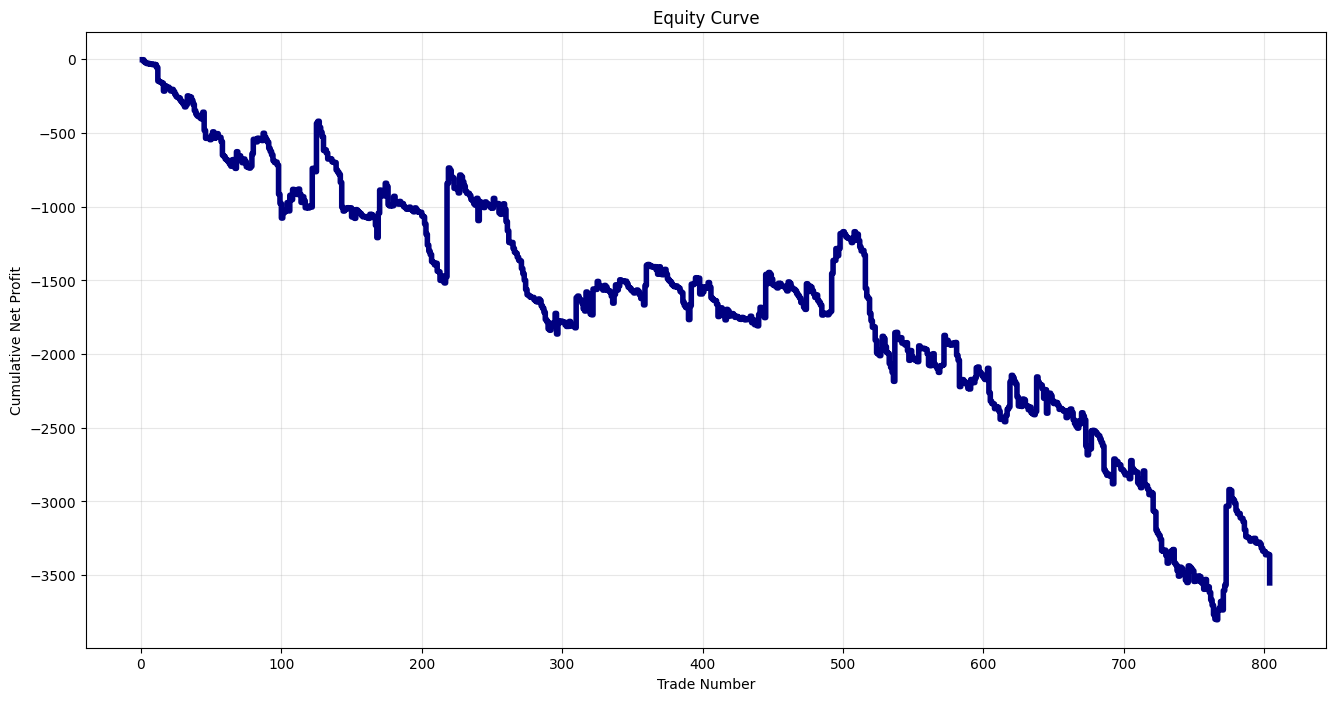

In [33]:
# Celda 9 — Generación de Gráficas (Equity)

import matplotlib.pyplot as plt
import os

os.makedirs(graph_output_directory, exist_ok=True)

plt.figure(figsize=(16,8))

plt.step(
    df['Trade number'],
    df['Cum. net profit'],
    where='post',
    linewidth=4,
    color='navy'
)

plt.title('Equity Curve')
plt.xlabel('Trade Number')
plt.ylabel('Cumulative Net Profit')
plt.grid(True, alpha=0.3)

output_path_equity_curve = os.path.join(graph_output_directory, 'Equity_Curve.jpg')

plt.savefig(output_path_equity_curve, bbox_inches='tight', dpi=300)
print(f'Gráfica Equity Curve guardada en: {output_path_equity_curve}')

plt.show()
plt.close()

Gráfica Equity y Drawdown guardada en: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/RB003_MNQ_A_T001/Equity_Drawdown.jpg


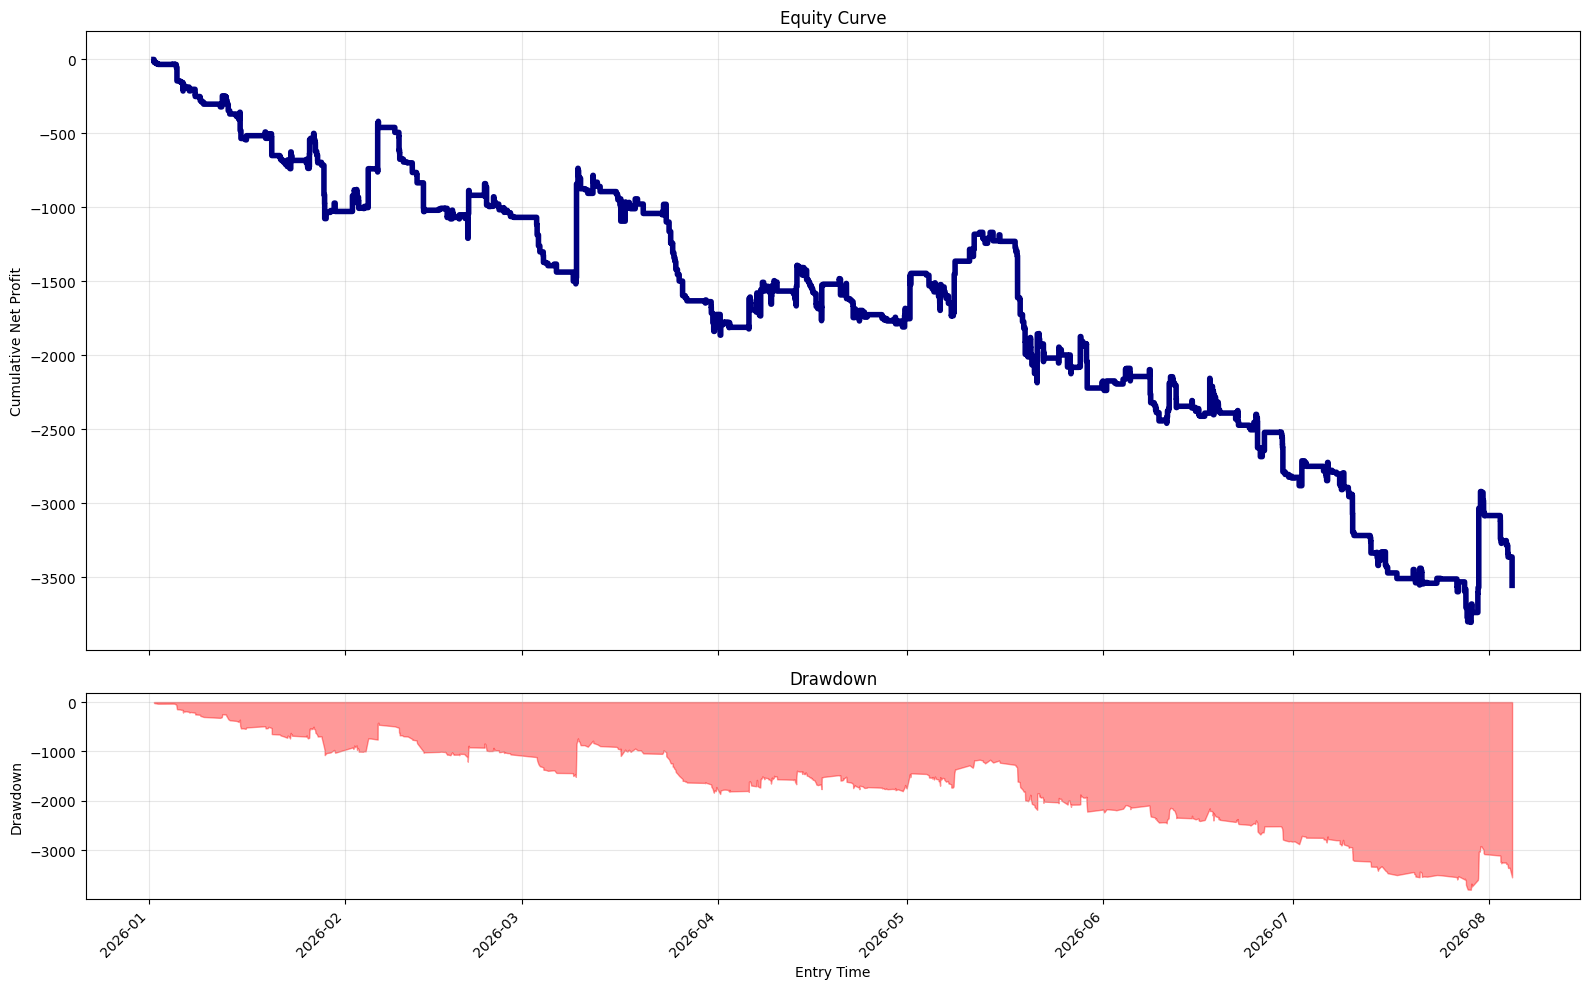

In [34]:
# Celda 10 — Generación de Graficas (Draw Down))

import os
import matplotlib.pyplot as plt

# Calculate HighWaterMark and Drawdown
df['HighWaterMark'] = df['Cum. net profit'].cummax()
df['Drawdown'] = df['Cum. net profit'] - df['HighWaterMark']

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16,10),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

# Plot Equity Curve
ax1.step(
    df['Entry time'],
    df['Cum. net profit'],
    where='post',
    color='navy',
    linewidth=4
)
ax1.set_title('Equity Curve')
ax1.set_ylabel('Cumulative Net Profit')
ax1.grid(alpha=0.3)

# Plot Drawdown
ax2.fill_between(
    df['Entry time'],
    df['Drawdown'],
    0,
    color='red',
    alpha=0.4
)
ax2.set_title('Drawdown')
ax2.set_ylabel('Drawdown')
ax2.grid(alpha=0.3)

# Set common labels and rotate x-axis labels for readability
plt.xlabel('Entry Time')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Construct the full output path for the equity and drawdown graph
output_path_equity_drawdown = os.path.join(graph_output_directory, 'Equity_Drawdown.jpg')

# Create the directory if it doesn't exist
os.makedirs(graph_output_directory, exist_ok=True)

# Save the figure before displaying it
fig.savefig(output_path_equity_drawdown, bbox_inches='tight', dpi=300)
print(f'Gráfica Equity y Drawdown guardada en: {output_path_equity_drawdown}')

plt.show()
plt.close(fig)

Gráfica Ganancia/Pérdida por Trade guardada en: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/RB003_MNQ_A_T001/Profit_Loss_Per_Trade.jpg


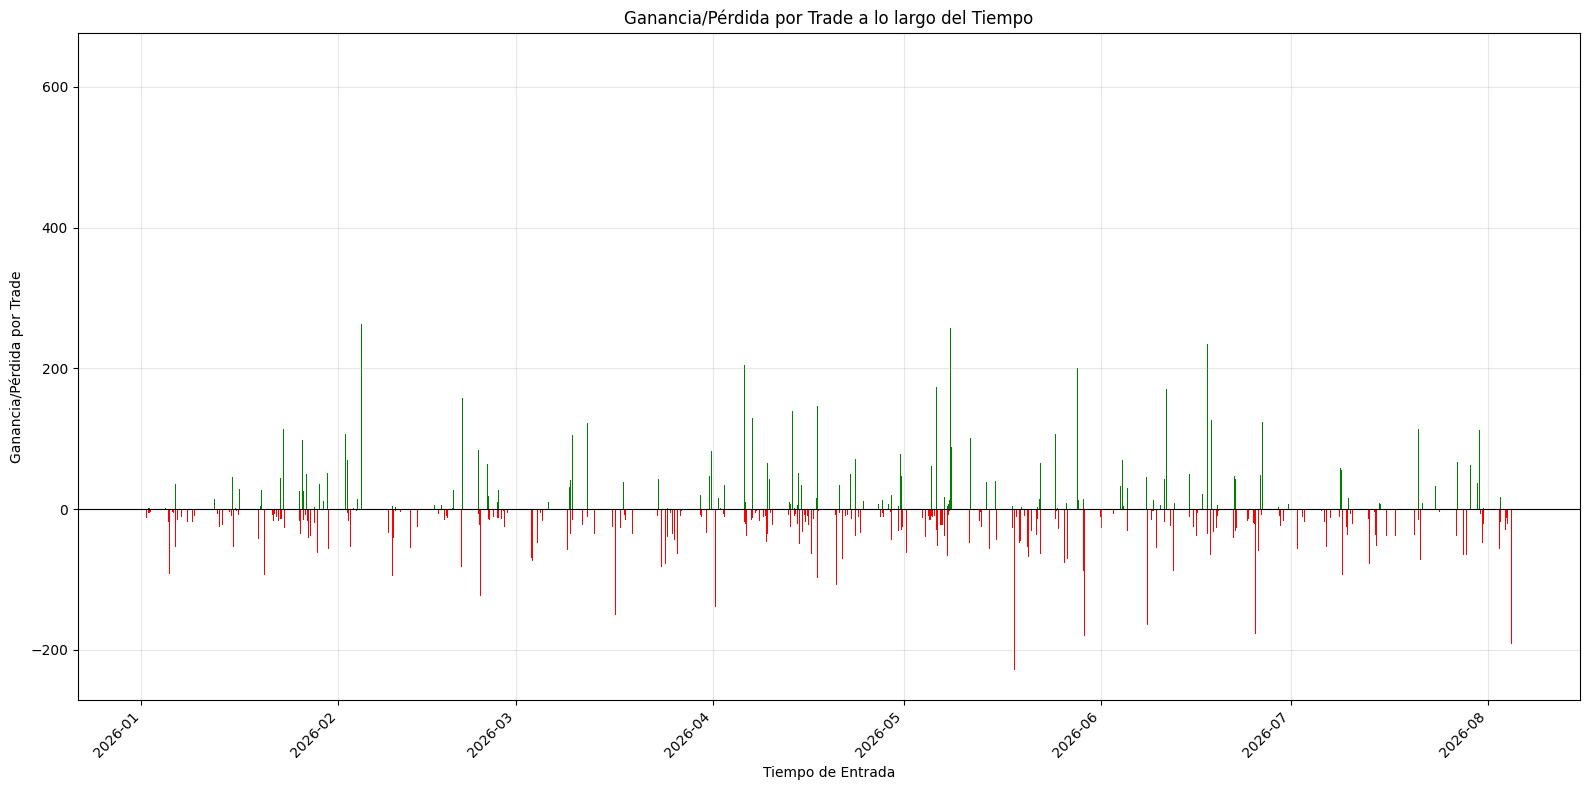

In [35]:
# Celda 11 — Generación de Graficas (Profit-Loos Trades)

import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

ax.bar(
    df['Entry time'],
    df['Profit'],
    color=['green' if p > 0 else 'red' for p in df['Profit']], # Green for profit, red for loss
    width=0.1 # Adjust width as needed for better visualization, changed from 0.5 to 0.1
)

ax.set_title('Ganancia/Pérdida por Trade a lo largo del Tiempo')
ax.set_xlabel('Tiempo de Entrada')
ax.set_ylabel('Ganancia/Pérdida por Trade')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()

# Construct the full output path for the profit/loss per trade graph
output_path_profit = os.path.join(graph_output_directory, 'Profit_Loss_Per_Trade.jpg')

# Create the directory if it doesn't exist
os.makedirs(graph_output_directory, exist_ok=True)

# Save the figure before displaying it
fig.savefig(output_path_profit, bbox_inches='tight', dpi=300)
print(f'Gráfica Ganancia/Pérdida por Trade guardada en: {output_path_profit}')

plt.show()
plt.close(fig)